# Task 1 - Iris Flower Classification

This notebook trains classification models to identify iris species from flower measurements. I kept the workflow simple: inspect the data, visualise it, train a few models, then compare the results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')

## Load the data

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
df = df.drop(columns='target')

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Basic inspection

In [3]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isna().sum())

df.describe()

Shape: (150, 5)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The dataset is already clean: all feature columns are numeric and there are no missing values. That makes it a good beginner dataset for classification.

## Visual exploration

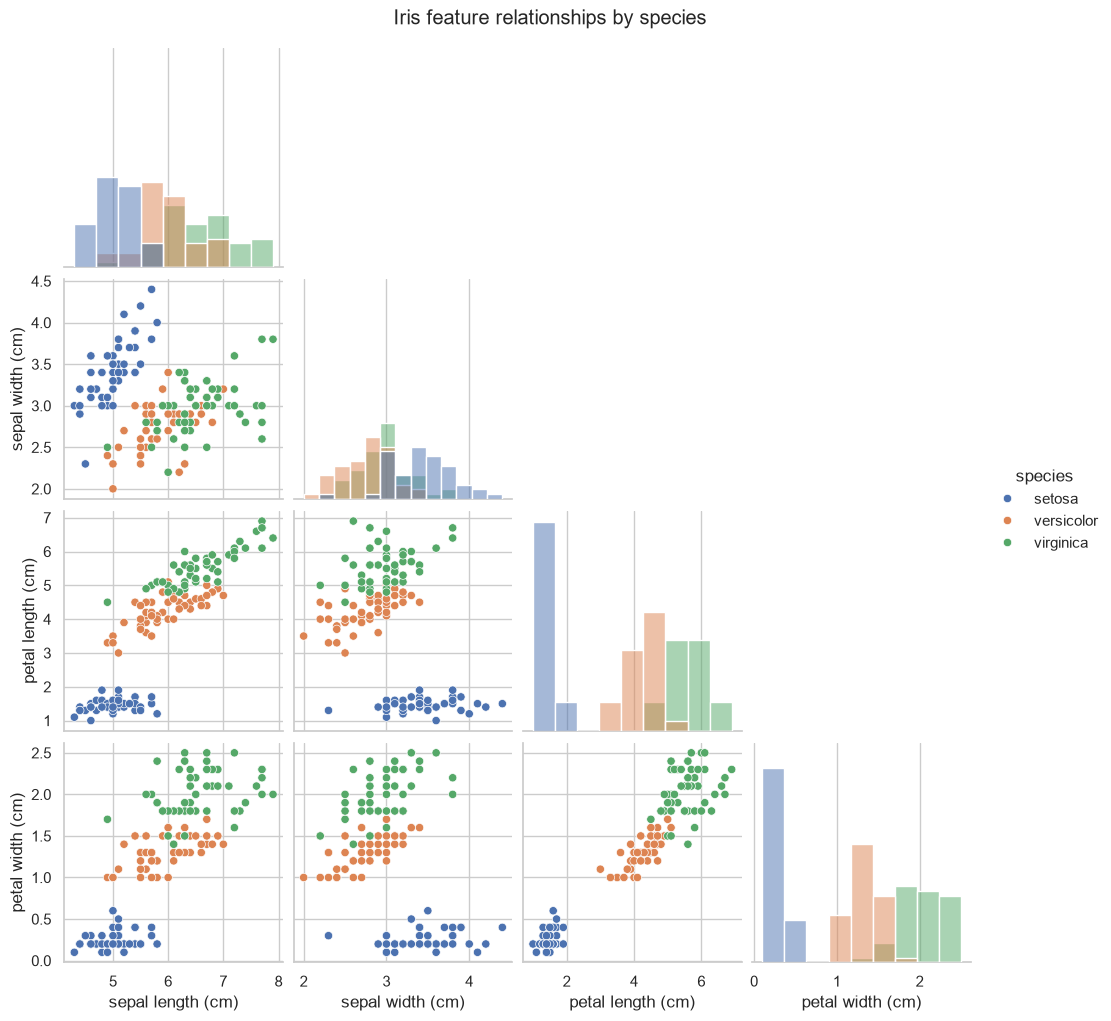

In [4]:
sns.pairplot(df, hue='species', corner=True, diag_kind='hist')
plt.suptitle('Iris feature relationships by species', y=1.02)
plt.show()

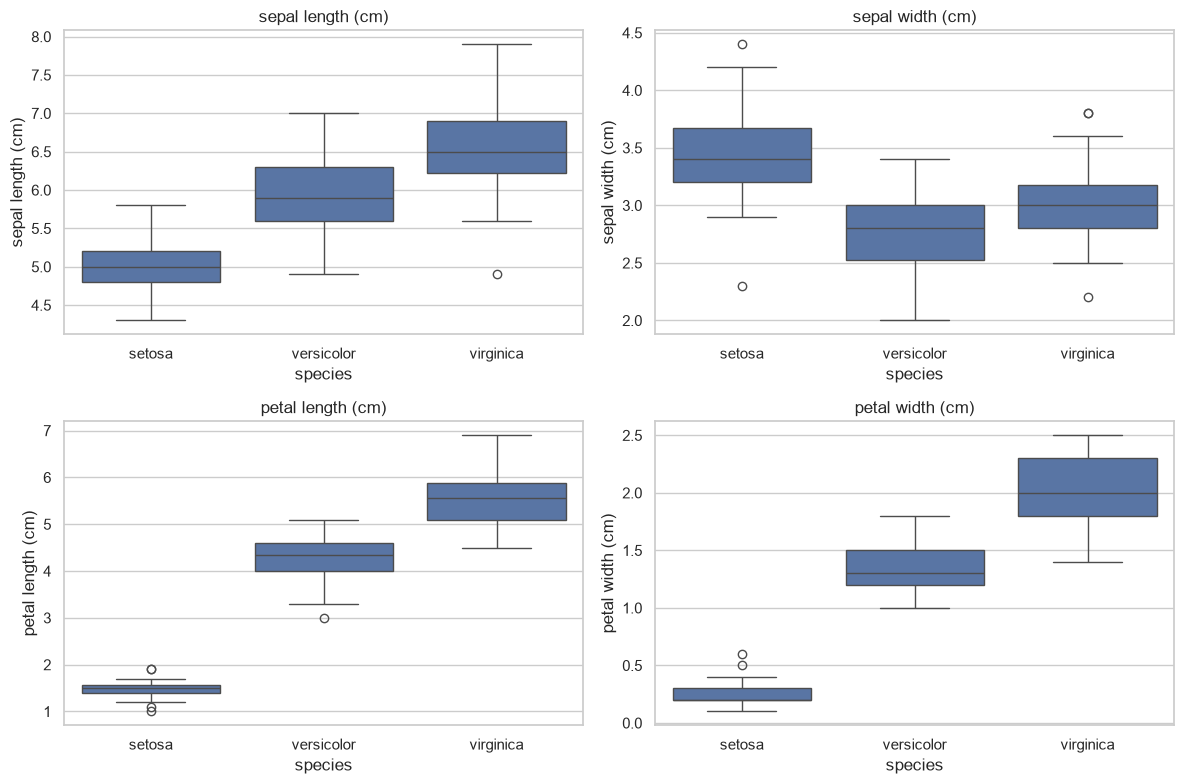

In [5]:
feature_cols = iris.feature_names
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.boxplot(data=df, x='species', y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Feature selection notes

Petal length and petal width separate the species much more clearly than the sepal measurements. Setosa is almost perfectly separated by petal size, while Versicolor and Virginica have some overlap but are still easier to distinguish using petal features.

## Train and compare models

In [6]:
X = df[feature_cols]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'K-Nearest Neighbours': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ]),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=120, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({'Model': name, 'Accuracy': accuracy_score(y_test, preds)})

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


Best model: Logistic Regression
Accuracy: 0.9333333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



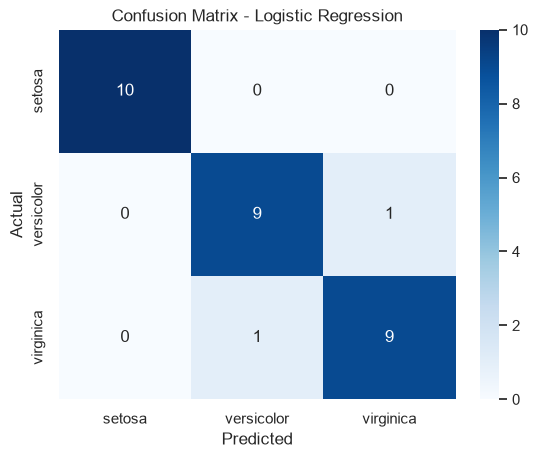

In [7]:
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
best_preds = best_model.predict(X_test)

print('Best model:', best_name)
print('Accuracy:', accuracy_score(y_test, best_preds))
print('\nClassification report:')
print(classification_report(y_test, best_preds))

cm = confusion_matrix(y_test, best_preds, labels=iris.target_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

## Conclusion

The best model is selected using test accuracy, with the classification report and confusion matrix used as a second check. The strong performance makes sense because petal length and petal width give clear separation between the species.